# 001 · EarlySign Core Concepts: (1) Ledger
This tutorial notebook demonstrates the core concept of the **statistical ledger** that `earlysign` is centered around.

We only use the bare functionality provided by `earlysign.core` for demonstrative purposes, and we start building on the convenience layers in the later notebooks.

- **Ledger is central**: every statistical step is a **write/read** to the ledger.
- Each event row has **payload** (data you write) and **labels** (context), and the ledger assigns **ts/uuid** automatically.

In this notebook, we demonstrate the procedure of a group sequential test in an A/B-testing scenario.
- We plan **five looks**, and the total type-I error rate is controlled by appropriately deriving the boundaries.
- **Information time**: the **sample-size fraction** $t = n/N_{\max}$.
- **Boundary**: Brownian motion approximation, O’Brien–Fleming one-sided (variant B being better than A)
  $$ c(t) = \frac{z_{1-\alpha}}{\sqrt{t}}, \quad \alpha=0.05. $$
  The alpha level is $\alpha=0.05$. For the O'Brien–Fleming style boundary we use the **one-sided 95th percentile** $z_{1-\alpha}\approx 1.64485$, yielding:
$$ c(t) = \frac{1.64485}{\sqrt{t}}. $$
- **Decision rule**: one-sided improvement of B over A:
  $$ Z \ge c(t) \ \Rightarrow\ \text{“reject A ≥ B” (i.e., B is better)}. $$
  Otherwise, **continue** to the next observation step.

Per look we do: **(1) Observe → (2) Compute Z → (3) Info time → (4) Boundary → (5) Decide**, writing each result to the ledger and immediately displaying the full ledger row(s).

**Look 1** is shown **step-by-step** across separate cells. **Looks 2–5** run in **one cell** with the same steps performed inside a loop.

In [1]:
import ibis, duckdb, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from earlysign.core.ledger import Ledger

# DataFrame visibility
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 0)
pd.set_option("display.max_columns", None)


# Utility
def show_new_and_context(ledger, prev_ts=None, context_tail=6):
    df = ledger.t.order_by("ts").execute()
    if prev_ts is None:
        return df.tail(context_tail)
    is_new = df["ts"] > prev_ts
    new_rows = df[is_new]
    if new_rows.empty:
        return df.tail(context_tail)
    context = df[~is_new].tail(context_tail)
    return pd.concat([context, new_rows], ignore_index=True)

### Demo Setup

In [2]:
class DataGenerator:
    # True rates (B slightly better)
    pA = 0.15
    pB = 0.17

    def __init__(self, seed=20250921):
        # Reproducibility
        self.rng = np.random.default_rng(seed)

    def sample(self, nA: int, nB: int):
        response_A = self.rng.binomial(1, self.pA, size=nA)
        response_B = self.rng.binomial(1, self.pB, size=nB)
        return int(response_A.sum()), int(response_B.sum())


data_generator = DataGenerator()

## Create the Ledger

In this `earlysign` library, we make an extensive use of the concept of **ledger**.

The ledger table has the following columns (`ts` and `uuid` are auto-managed by the `Ledger` class):
- `ts`: timestamp
- `uuid`: unique identifier
- `payload_type`: a short tag for the event type
- `payload`: an arbitrary json storing the event data
- `labels`: a dictionary storing contextual labels

We create an in-memory DuckDB connection and ensure the ledger table exists.

In [3]:
con = ibis.duckdb.connect(":memory:")
ledger = Ledger(con, "events")
ledger.ensure()

# Empty schema view (all columns)
ledger.t.limit(0).execute()

,uuid,ts,payload_type,payload,labels


## Register the experiment design

We store the design as one event in the ledger: the payload describes the test,
and labels mark the experiment id. We keep the design simple and **fixed** for this tutorial.

In [4]:
alpha = 0.05
z_one_sided = 1.6448536269514722
looks = [0.40, 0.50, 0.70, 1.00]
Nmax_per_arm = 1000
n_plan = [int(t * Nmax_per_arm) for t in looks]

design = {
    "test_name": "AB_binomial_rate_diff",
    "alpha": alpha,
    "sides": "one-sided (B better than A)",
    "looks": looks,
    "planned_n_per_look": n_plan,
    "metric": "conversion",
    "variant_labels": {"A": "control", "B": "treatment"},
}
labels = {"experiment": "demo_core_001"}

ledger.insert(payload_type="DesignAB", payload=design, labels=labels)
ledger.t.filter(ledger.t.payload_type == "DesignAB").order_by("ts").execute()

,uuid,ts,payload_type,payload,labels
0,bb403e8a359f4bb489d37a6f4328803f,2025-09-21 16:09:19.972139+00:00,DesignAB,"{'alpha': 0.05, 'looks': [0.4, 0.5, 0.7, 1.0], 'metric': 'conversion', 'planned_n_per_look': [400, 500, 700, 1000], 'sides': 'one-sided (B better than A)', 'test_name': 'AB_binomial_rate_diff', 'variant_labels': {'A': 'control', 'B': 'treatment'}}",{'experiment': 'demo_core_001'}


You can see that your crafted payload has been registered into the ledger, along with the auto-recorded record ID and timestamp.

# Look 1 — step-by-step

We now execute the first observation and the first look.
As far as this tutorial is concerned, the information time refers to the ratio of the current sample size to the maximum planned sample size.


### Step 1. Observe and write observation

We add observations up to the planned first look size and write the cumulative counts as-is in the **payload**.
This tutorial keeps payloads simple and directly readable.

In [5]:
cum = {"A": {"n": 0, "m": 0}, "B": {"n": 0, "m": 0}}

target = n_plan[0]
prev_ts = ledger.t.ts.max().execute()

addA = target - cum["A"]["n"]
addB = target - cum["B"]["n"]

mA, mB = data_generator.sample(addA, addB)

cum["A"]["n"] += addA
cum["B"]["n"] += addB
cum["A"]["m"] += mA
cum["B"]["m"] += mB

ledger.insert(
    payload_type="Observation",
    payload={
        "look": 1,
        "A": {"success": cum["A"]["m"], "n": cum["A"]["n"]},
        "B": {"success": cum["B"]["m"], "n": cum["B"]["n"]},
    },
    labels={**labels, "look": 1},
)

show_new_and_context(ledger, prev_ts)

,uuid,ts,payload_type,payload,labels
0,bb403e8a359f4bb489d37a6f4328803f,2025-09-21 16:09:19.972139+00:00,DesignAB,"{'alpha': 0.05, 'looks': [0.4, 0.5, 0.7, 1.0], 'metric': 'conversion', 'planned_n_per_look': [400, 500, 700, 1000], 'sides': 'one-sided (B better than A)', 'test_name': 'AB_binomial_rate_diff', 'variant_labels': {'A': 'control', 'B': 'treatment'}}",{'experiment': 'demo_core_001'}
1,6983ccfd066b4c588a26282e750808fa,2025-09-21 16:09:20.011652+00:00,Observation,"{'A': {'n': 400, 'success': 54}, 'B': {'n': 400, 'success': 76}, 'look': 1}","{'experiment': 'demo_core_001', 'look': 1}"


### Step 2. Compute Wald Z and write

We compute the Wald Z for the difference in proportions \(B-A\):
$$
Z = \frac{\hat p_B - \hat p_A}{\sqrt{\hat p_A(1-\hat p_A)/n_A + \hat p_B(1-\hat p_B)/n_B}}.
$$
We then store it with the look label.



In [6]:
def wald_z_from_counts(mA, nA, mB, nB, eps=1e-12):
    pAhat = mA / max(nA, eps)
    pBhat = mB / max(nB, eps)
    var = pAhat * (1 - pAhat) / max(nA, eps) + pBhat * (1 - pBhat) / max(nB, eps)
    if var <= 0:
        return float("nan")
    return (pBhat - pAhat) / math.sqrt(var)


prev_ts = ledger.t.ts.max().execute()
z1 = wald_z_from_counts(cum["A"]["m"], cum["A"]["n"], cum["B"]["m"], cum["B"]["n"])
ledger.insert(
    payload_type="WaldZ",
    payload={"look": 1, "wald_z": z1},
    labels={**labels, "look": 1},
)

show_new_and_context(ledger, prev_ts)

,uuid,ts,payload_type,payload,labels
0,bb403e8a359f4bb489d37a6f4328803f,2025-09-21 16:09:19.972139+00:00,DesignAB,"{'alpha': 0.05, 'looks': [0.4, 0.5, 0.7, 1.0], 'metric': 'conversion', 'planned_n_per_look': [400, 500, 700, 1000], 'sides': 'one-sided (B better than A)', 'test_name': 'AB_binomial_rate_diff', 'variant_labels': {'A': 'control', 'B': 'treatment'}}",{'experiment': 'demo_core_001'}
1,6983ccfd066b4c588a26282e750808fa,2025-09-21 16:09:20.011652+00:00,Observation,"{'A': {'n': 400, 'success': 54}, 'B': {'n': 400, 'success': 76}, 'look': 1}","{'experiment': 'demo_core_001', 'look': 1}"
2,3026c93a4c5044f698524a72c5519f4e,2025-09-21 16:09:20.026942+00:00,WaldZ,"{'look': 1, 'wald_z': 2.1143097495846037}","{'experiment': 'demo_core_001', 'look': 1}"


You can see that we have added the first computed statistic value to the ledger now.

### Step 3. Compute information time, O’Brien–Fleming boundary, and write them

Information time \(t\) is the **sample-size ratio** (average over arms):
$$ t = \frac{1}{2}\left(\frac{n_A + n_B}{N_{\max}}\right). $$
We compute it and store it in the ledger.

Then, reading the current information time from the ledger, we compute the boundary for this look.

Using the Brownian approximation with an O’Brien–Fleming one-sided design,
$$ c(t) = \frac{z_{1-\alpha}}{\sqrt{t}}. $$
We store the boundary as a pair `(upper=c, lower=-c)` on the **Z-scale**.

In [7]:
# Compute the "information time" (how much progress we have made in the sample collection so far)
def info_time_from_counts(nA, nB, Nmax):
    return 0.5 * (nA / Nmax + nB / Nmax)


prev_ts = ledger.t.ts.max().execute()
t1 = info_time_from_counts(cum["A"]["n"], cum["B"]["n"], Nmax_per_arm)
ledger.insert(
    payload_type="InfoTime", payload={"look": 1, "t": t1}, labels={**labels, "look": 1}
)


# Compute the boundary of the statistical test
def boundary_obf_one_sided(t, z_one_sided=1.6448536):
    return z_one_sided / math.sqrt(max(t, 1e-12))


c1 = boundary_obf_one_sided(t1, z_one_sided=z_one_sided)
ledger.insert(
    payload_type="GSTBoundary",
    payload={"look": 1, "upper": c1, "lower": -c1, "scale": "z"},
    labels={**labels, "look": 1},
)

show_new_and_context(ledger, prev_ts)

,uuid,ts,payload_type,payload,labels
0,bb403e8a359f4bb489d37a6f4328803f,2025-09-21 16:09:19.972139+00:00,DesignAB,"{'alpha': 0.05, 'looks': [0.4, 0.5, 0.7, 1.0], 'metric': 'conversion', 'planned_n_per_look': [400, 500, 700, 1000], 'sides': 'one-sided (B better than A)', 'test_name': 'AB_binomial_rate_diff', 'variant_labels': {'A': 'control', 'B': 'treatment'}}",{'experiment': 'demo_core_001'}
1,6983ccfd066b4c588a26282e750808fa,2025-09-21 16:09:20.011652+00:00,Observation,"{'A': {'n': 400, 'success': 54}, 'B': {'n': 400, 'success': 76}, 'look': 1}","{'experiment': 'demo_core_001', 'look': 1}"
2,3026c93a4c5044f698524a72c5519f4e,2025-09-21 16:09:20.026942+00:00,WaldZ,"{'look': 1, 'wald_z': 2.1143097495846037}","{'experiment': 'demo_core_001', 'look': 1}"
3,f2550c2efaf24550bb1e654364d562fe,2025-09-21 16:09:20.044061+00:00,InfoTime,"{'look': 1, 't': 0.4}","{'experiment': 'demo_core_001', 'look': 1}"
4,511482d18c0c4c50a2b65b955a7b8da5,2025-09-21 16:09:20.047121+00:00,GSTBoundary,"{'look': 1, 'lower': -2.600741939377787, 'scale': 'z', 'upper': 2.600741939377787}","{'experiment': 'demo_core_001', 'look': 1}"


We now have the threshold to compare the statistic value against.

### Step 4. Make decision and write

One-sided improvement of B over A: **reject** when $Z \ge c(t)$.
Otherwise, **continue**.


In [8]:
prev_ts = ledger.t.ts.max().execute()
if np.isfinite(z1) and (z1 >= c1):
    dec1 = {"look": 1, "signal": "reject_A_ge_B", "reason": f"z={z1:.3f} >= c={c1:.3f}"}
else:
    dec1 = {"look": 1, "signal": "continue", "reason": f"z={z1:.3f}, c={c1:.3f}"}

ledger.insert(payload_type="DecisionSignal", payload=dec1, labels={**labels, "look": 1})

show_new_and_context(ledger, prev_ts)

,uuid,ts,payload_type,payload,labels
0,bb403e8a359f4bb489d37a6f4328803f,2025-09-21 16:09:19.972139+00:00,DesignAB,"{'alpha': 0.05, 'looks': [0.4, 0.5, 0.7, 1.0], 'metric': 'conversion', 'planned_n_per_look': [400, 500, 700, 1000], 'sides': 'one-sided (B better than A)', 'test_name': 'AB_binomial_rate_diff', 'variant_labels': {'A': 'control', 'B': 'treatment'}}",{'experiment': 'demo_core_001'}
1,6983ccfd066b4c588a26282e750808fa,2025-09-21 16:09:20.011652+00:00,Observation,"{'A': {'n': 400, 'success': 54}, 'B': {'n': 400, 'success': 76}, 'look': 1}","{'experiment': 'demo_core_001', 'look': 1}"
2,3026c93a4c5044f698524a72c5519f4e,2025-09-21 16:09:20.026942+00:00,WaldZ,"{'look': 1, 'wald_z': 2.1143097495846037}","{'experiment': 'demo_core_001', 'look': 1}"
3,f2550c2efaf24550bb1e654364d562fe,2025-09-21 16:09:20.044061+00:00,InfoTime,"{'look': 1, 't': 0.4}","{'experiment': 'demo_core_001', 'look': 1}"
4,511482d18c0c4c50a2b65b955a7b8da5,2025-09-21 16:09:20.047121+00:00,GSTBoundary,"{'look': 1, 'lower': -2.600741939377787, 'scale': 'z', 'upper': 2.600741939377787}","{'experiment': 'demo_core_001', 'look': 1}"
5,22c838e777af443f94948d89f998eabe,2025-09-21 16:09:20.065096+00:00,DecisionSignal,"{'look': 1, 'reason': 'z=2.114, c=2.601', 'signal': 'continue'}","{'experiment': 'demo_core_001', 'look': 1}"


At this time, the signal says we should continue to the next look, instead of rejecting the null.

So far, we have demonstrated one set of procedures (one look) of interim analysis:
- `Observation` → counts up to look 1.
- `WaldZ` → interim statistic.
- `InfoTime` → information time \(t\).
- `GSTBoundary` → O’Brien–Fleming upper boundary on Z-scale.
- `DecisionSignal` → interim decision.

All results were **written** in the ledger and they were used in the subsequent calculations/decisions.

Now, we will repeat these steps according to the predetermined design.

# Remaining Looks — same steps inside a single loop

We now execute the rest of the experiment up to the final look at **t ≈ 1.00**.

In [9]:
prev_ts = ledger.t.ts.max().execute()

for lk in range(2, len(looks) + 1):
    # Step 1: Observe
    target = n_plan[lk - 1]
    addA = target - cum["A"]["n"]
    addB = target - cum["B"]["n"]
    mA, mB = data_generator.sample(addA, addB)
    cum["A"]["n"] += addA
    cum["B"]["n"] += addB
    cum["A"]["m"] += mA
    cum["B"]["m"] += mB
    obs = {
        "look": lk,
        "A": {"success": cum["A"]["m"], "n": cum["A"]["n"]},
        "B": {"success": cum["B"]["m"], "n": cum["B"]["n"]},
    }
    ledger.insert(
        payload_type="Observation", payload=obs, labels={**labels, "look": lk}
    )

    # Step 2: Z
    z = ((cum["B"]["m"] / cum["B"]["n"]) - (cum["A"]["m"] / cum["A"]["n"])) / math.sqrt(
        (cum["A"]["m"] / cum["A"]["n"])
        * (1 - cum["A"]["m"] / cum["A"]["n"])
        / cum["A"]["n"]
        + (cum["B"]["m"] / cum["B"]["n"])
        * (1 - cum["B"]["m"] / cum["B"]["n"])
        / cum["B"]["n"]
    )
    ledger.insert(
        payload_type="WaldZ",
        payload={"look": lk, "wald_z": z},
        labels={**labels, "look": lk},
    )

    # Step 3: info time and boundary
    t = 0.5 * (cum["A"]["n"] / Nmax_per_arm + cum["B"]["n"] / Nmax_per_arm)
    ledger.insert(
        payload_type="InfoTime",
        payload={"look": lk, "t": t},
        labels={**labels, "look": lk},
    )

    c = z_one_sided / math.sqrt(max(t, 1e-12))
    ledger.insert(
        payload_type="GSTBoundary",
        payload={"look": lk, "upper": c, "lower": -c, "scale": "z"},
        labels={**labels, "look": lk},
    )

    # Step 4: decision
    if np.isfinite(z) and (z >= c):
        dec = {
            "look": lk,
            "signal": "reject_A_ge_B",
            "reason": f"z={z:.3f} >= c={c:.3f}",
        }
    else:
        dec = {"look": lk, "signal": "continue", "reason": f"z={z:.3f}, c={c:.3f}"}
    ledger.insert(
        payload_type="DecisionSignal", payload=dec, labels={**labels, "look": lk}
    )

    if "reject" in dec["signal"]:
        ledger.insert(
            payload_type="Log",
            payload={
                "message": "We terminate the experiment early in light of the sequential testing procedure. The null hypothesis has been rejected. Let's go with the alternative variant!"
            },
        )

display(show_new_and_context(ledger, prev_ts))

,uuid,ts,payload_type,payload,labels
0,bb403e8a359f4bb489d37a6f4328803f,2025-09-21 16:09:19.972139+00:00,DesignAB,"{'alpha': 0.05, 'looks': [0.4, 0.5, 0.7, 1.0], 'metric': 'conversion', 'planned_n_per_look': [400, 500, 700, 1000], 'sides': 'one-sided (B better than A)', 'test_name': 'AB_binomial_rate_diff', 'variant_labels': {'A': 'control', 'B': 'treatment'}}",{'experiment': 'demo_core_001'}
1,6983ccfd066b4c588a26282e750808fa,2025-09-21 16:09:20.011652+00:00,Observation,"{'A': {'n': 400, 'success': 54}, 'B': {'n': 400, 'success': 76}, 'look': 1}","{'experiment': 'demo_core_001', 'look': 1}"
2,3026c93a4c5044f698524a72c5519f4e,2025-09-21 16:09:20.026942+00:00,WaldZ,"{'look': 1, 'wald_z': 2.1143097495846037}","{'experiment': 'demo_core_001', 'look': 1}"
3,f2550c2efaf24550bb1e654364d562fe,2025-09-21 16:09:20.044061+00:00,InfoTime,"{'look': 1, 't': 0.4}","{'experiment': 'demo_core_001', 'look': 1}"
4,511482d18c0c4c50a2b65b955a7b8da5,2025-09-21 16:09:20.047121+00:00,GSTBoundary,"{'look': 1, 'lower': -2.600741939377787, 'scale': 'z', 'upper': 2.600741939377787}","{'experiment': 'demo_core_001', 'look': 1}"
5,22c838e777af443f94948d89f998eabe,2025-09-21 16:09:20.065096+00:00,DecisionSignal,"{'look': 1, 'reason': 'z=2.114, c=2.601', 'signal': 'continue'}","{'experiment': 'demo_core_001', 'look': 1}"
6,efceb4476159452494f019c33df76eba,2025-09-21 16:09:20.084383+00:00,Observation,"{'A': {'n': 500, 'success': 66}, 'B': {'n': 500, 'success': 96}, 'look': 2}","{'experiment': 'demo_core_001', 'look': 2}"
7,e9d435a3f4ab48819b933eeeddd0dc41,2025-09-21 16:09:20.087252+00:00,WaldZ,"{'look': 2, 'wald_z': 2.5833670608456836}","{'experiment': 'demo_core_001', 'look': 2}"
8,acb8e4eaca594c2f84187964a6af85a0,2025-09-21 16:09:20.090700+00:00,InfoTime,"{'look': 2, 't': 0.5}","{'experiment': 'demo_core_001', 'look': 2}"
9,44947e695c254c7eae99f7a7bb9103d0,2025-09-21 16:09:20.093463+00:00,GSTBoundary,"{'look': 2, 'lower': -2.326174307353347, 'scale': 'z', 'upper': 2.326174307353347}","{'experiment': 'demo_core_001', 'look': 2}"


# Consolidated reporting

### Summarize looks

In [10]:
# Source of truth: the ledger
info = {
    r["payload"]["look"]: r["payload"]["t"]
    for r in ledger.t.filter(ledger.t.payload_type == "InfoTime")
    .execute()
    .to_dict("records")
}
wald = {
    r["payload"]["look"]: r["payload"]["wald_z"]
    for r in ledger.t.filter(ledger.t.payload_type == "WaldZ")
    .execute()
    .to_dict("records")
}
crit = {
    r["payload"]["look"]: r["payload"]["upper"]
    for r in ledger.t.filter(ledger.t.payload_type == "GSTBoundary")
    .execute()
    .to_dict("records")
}
dec = {
    r["payload"]["look"]: r["payload"]
    for r in ledger.t.filter(ledger.t.payload_type == "DecisionSignal")
    .execute()
    .to_dict("records")
}

rows = []
for lk in sorted(info.keys()):
    rows.append(
        {
            "look": lk,
            "info_time": info[lk],
            "wald_z": wald[lk],
            "crit_upper": crit[lk],
            "decision": dec[lk]["signal"],
            "reason": dec[lk]["reason"],
        }
    )
pd.DataFrame(rows).sort_values("look")

,look,info_time,wald_z,crit_upper,decision,reason
0,1,0.4,2.114310,2.600742,continue,"z=2.114, c=2.601"
1,2,0.5,2.583367,2.326174,reject_A_ge_B,z=2.583 >= c=2.326
2,3,0.7,3.434580,1.965976,reject_A_ge_B,z=3.435 >= c=1.966
3,4,1.0,2.863147,1.644854,reject_A_ge_B,z=2.863 >= c=1.645


### Plot Z trajectory vs O’Brien–Fleming boundary

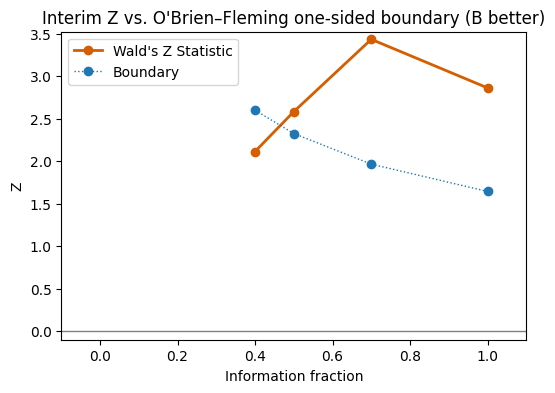

In [11]:
tvals = [info[k] for k in sorted(info.keys())]
zvals = [wald[k] for k in sorted(wald.keys())]
cvals = [crit[k] for k in sorted(crit.keys())]

plt.figure(figsize=(6, 4))
plt.plot(
    tvals, zvals, marker="o", linewidth=2.0, label="Wald's Z Statistic", color="#d55e00"
)
plt.plot(
    tvals, cvals, marker="o", linewidth=1.0, linestyle=":", color="C0", label="Boundary"
)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, None)
plt.xlabel("Information fraction")
plt.ylabel("Z")
plt.axhline(0, color="gray", linewidth=1, linestyle="-")
plt.title("Interim Z vs. O'Brien–Fleming one-sided boundary (B better)")
plt.legend()
plt.show()

### Full ledger (recent context retained)

In [12]:
# Show the last ~25 rows for audit (all columns intact)
df_all = ledger.t.order_by("ts").execute()
df_all.tail(25)

,uuid,ts,payload_type,payload,labels
0,bb403e8a359f4bb489d37a6f4328803f,2025-09-21 16:09:19.972139+00:00,DesignAB,"{'alpha': 0.05, 'looks': [0.4, 0.5, 0.7, 1.0], 'metric': 'conversion', 'planned_n_per_look': [400, 500, 700, 1000], 'sides': 'one-sided (B better than A)', 'test_name': 'AB_binomial_rate_diff', 'variant_labels': {'A': 'control', 'B': 'treatment'}}",{'experiment': 'demo_core_001'}
1,6983ccfd066b4c588a26282e750808fa,2025-09-21 16:09:20.011652+00:00,Observation,"{'A': {'n': 400, 'success': 54}, 'B': {'n': 400, 'success': 76}, 'look': 1}","{'experiment': 'demo_core_001', 'look': 1}"
2,3026c93a4c5044f698524a72c5519f4e,2025-09-21 16:09:20.026942+00:00,WaldZ,"{'look': 1, 'wald_z': 2.1143097495846037}","{'experiment': 'demo_core_001', 'look': 1}"
3,f2550c2efaf24550bb1e654364d562fe,2025-09-21 16:09:20.044061+00:00,InfoTime,"{'look': 1, 't': 0.4}","{'experiment': 'demo_core_001', 'look': 1}"
4,511482d18c0c4c50a2b65b955a7b8da5,2025-09-21 16:09:20.047121+00:00,GSTBoundary,"{'look': 1, 'lower': -2.600741939377787, 'scale': 'z', 'upper': 2.600741939377787}","{'experiment': 'demo_core_001', 'look': 1}"
5,22c838e777af443f94948d89f998eabe,2025-09-21 16:09:20.065096+00:00,DecisionSignal,"{'look': 1, 'reason': 'z=2.114, c=2.601', 'signal': 'continue'}","{'experiment': 'demo_core_001', 'look': 1}"
6,efceb4476159452494f019c33df76eba,2025-09-21 16:09:20.084383+00:00,Observation,"{'A': {'n': 500, 'success': 66}, 'B': {'n': 500, 'success': 96}, 'look': 2}","{'experiment': 'demo_core_001', 'look': 2}"
7,e9d435a3f4ab48819b933eeeddd0dc41,2025-09-21 16:09:20.087252+00:00,WaldZ,"{'look': 2, 'wald_z': 2.5833670608456836}","{'experiment': 'demo_core_001', 'look': 2}"
8,acb8e4eaca594c2f84187964a6af85a0,2025-09-21 16:09:20.090700+00:00,InfoTime,"{'look': 2, 't': 0.5}","{'experiment': 'demo_core_001', 'look': 2}"
9,44947e695c254c7eae99f7a7bb9103d0,2025-09-21 16:09:20.093463+00:00,GSTBoundary,"{'look': 2, 'lower': -2.326174307353347, 'scale': 'z', 'upper': 2.326174307353347}","{'experiment': 'demo_core_001', 'look': 2}"


# Closing notes and next steps

- We recorded all steps as immutable events in the ledger.
- After each write, we immediately inspected the full ledger rows for that look.
- This demonstrated a **two-look one-sided** sequential test for B's improvement using only `earlysign.core`.
- In higher layers (`framework`, `templates`, `api`), the same idea remains: **everything is ledger operations**.